### Heating Electrification Bill Savings with and without Solar PV
This notebook uses ResStock data and NREL's PySAM to calculate the difference in bill savings when electrifying heating with and without solar PV. 

#### Methodology
1) Pull hourly electricity and gas loads from ResStock under Upgrade 0 (baseline) and Upgrade 7 (heat pump with basic insulation)
2) Size a PV system based on the ResStock building energy simulation's roof area and max load
3) Calculate the hourly PV generation and estimate net hourly load with a heat pump *and* solar PV
4) Calculate total bills (electricity + gas) for all three scenarios:
    - A. Baseline
    - B. Heat Pump 
    - C. Heat Pump + Solar
5) Plot differences

#### Notes
The housing typology used for this analysis is a single-family detached, owner-occupied home whose primary heating fuel is natural gas

In [1]:
import sys,os
from pathlib import Path

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from solar_bill_analysis import (
    build_building_hourly_profiles,
    PVSimulationConfig,
    compute_pv_for_building,
    compute_bills_for_buildings,
    plot_city_bill_savings,
    build_hpxml_zip_path
)

In [2]:
# Path to ResStock metadata CSV/parquet
METADATA_PATH = "../data/upgrade07.parquet"

metadata = pd.read_parquet(METADATA_PATH).reset_index(drop=False)

# Make sure bldg_id is string
metadata["bldg_id"] = metadata["bldg_id"].astype(str)

# Filter to buildings with
# 1) Primary heating fuels is natural gas
# 2) Heat pump upgrade is applicable
# 3) Owner-occupied, single family home
# 4) Located in target cities

cities = ['MI, Detroit', 'CA, Los Angeles', 'NJ, Newark', 'WI, Green Bay', 'OH, Cleveland', 'OR, Portland', 'CO, Denver']

metadata_filt = metadata[
    (metadata["in.heating_fuel"] == "Natural Gas") &
    (metadata["applicability"] == True) &
    (metadata["in.geometry_building_type_acs"] == "Single-Family Detached") &
    (metadata["in.tenure"] == "Owner") &
    (metadata["in.city"].isin(cities))
]

bldg_ids = metadata_filt["bldg_id"].tolist()

print(f"Total buildings: {len(metadata_filt)}")


Total buildings: 2687


In [3]:
BUCKET = "oedi-data-lake"

# Base prefix for individual-building timeseries
TIMESERIES_BASE_PREFIX = (
    "nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/"
    "2024/resstock_tmy3_release_2/timeseries_individual_buildings/by_state"
)

hourly_profiles = build_building_hourly_profiles(
    bldg_ids=bldg_ids,
    metadata_df=metadata_filt,
    upgrades=("0", "7"),
    bucket=BUCKET,
    base_prefix=TIMESERIES_BASE_PREFIX,
    region="us-west-2",
    chunk_size=250,
    max_workers=8,
    metadata_id_col="bldg_id",
)

In [4]:
# Base URL for weather files (TMY3)
WEATHER_BASE_PREFIX = (
    "https://oedi-data-lake.s3.amazonaws.com/"
    "nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/"
    "2024/resstock_tmy3_release_2/weather"
)

pv_config = PVSimulationConfig(
    sizing_mode="min",  
    watts_per_ft2=15.0,
    target_solar_fraction=0.8,   # used if sizing_mode="load"
    assumed_cf=0.18,
    dc_ac_ratio=1.2,
    gcr=0.4,
    tilt_default_deg=25.0,
    export_rate_per_kwh=0.05,    # example export credit for net billing
)

In [5]:
# # Filter hourly profiles for Upgrade 7
# hourly_u7 = hourly_profiles[hourly_profiles["upgrade"] == "7"].copy()

# pv_records = []

# for bldg_id, grp in hourly_u7.groupby("bldg_id"):
#     grp = grp.sort_values("ts_hour")
    
#     # Metadata row for this building
#     meta_row = metadata_filt.loc[metadata_filt["bldg_id"] == bldg_id].iloc[0]
    
#     # Hourly Upgrade 7 load as a Series
#     hourly_load_u7 = grp.set_index("ts_hour")["elec_kwh"]
    
#     # Build teh hpxml url
#     hpxml_url = build_hpxml_zip_path(bldg_id, upgrade="0")
    
#     # Compute PV generation
#     pv_kwh, system_kw = compute_pv_for_building(
#         metadata_row=meta_row,
#         hourly_u7=hourly_load_u7,
#         pv_config=pv_config,
#         weather_base_prefix=WEATHER_BASE_PREFIX,
#         hpxml_zip_path=hpxml_url,
#     )
    
#     pv_df_bldg = pv_kwh.to_frame("pv_kwh").reset_index()
#     pv_df_bldg["bldg_id"] = bldg_id
#     pv_df_bldg["system_kw"] = system_kw
    
#     pv_records.append(pv_df_bldg)

# pv_all = pd.concat(pv_records, ignore_index=True)

# pv_all.to_csv("pv_all.csv", index=False)

pv_all = pd.read_csv("pv_all.csv")


In [6]:
# Compute per-building bills and savings
bills_df = compute_bills_for_buildings(
    hourly_df=hourly_profiles,
    metadata_df=metadata_filt,
    pv_df=pv_all[["bldg_id", "ts_hour", "pv_kwh"]],
    export_rate_per_kwh=pv_config.export_rate_per_kwh,
    baseline_upgrade="0",
    hp_upgrade="7",
    metadata_id_col="bldg_id",
)

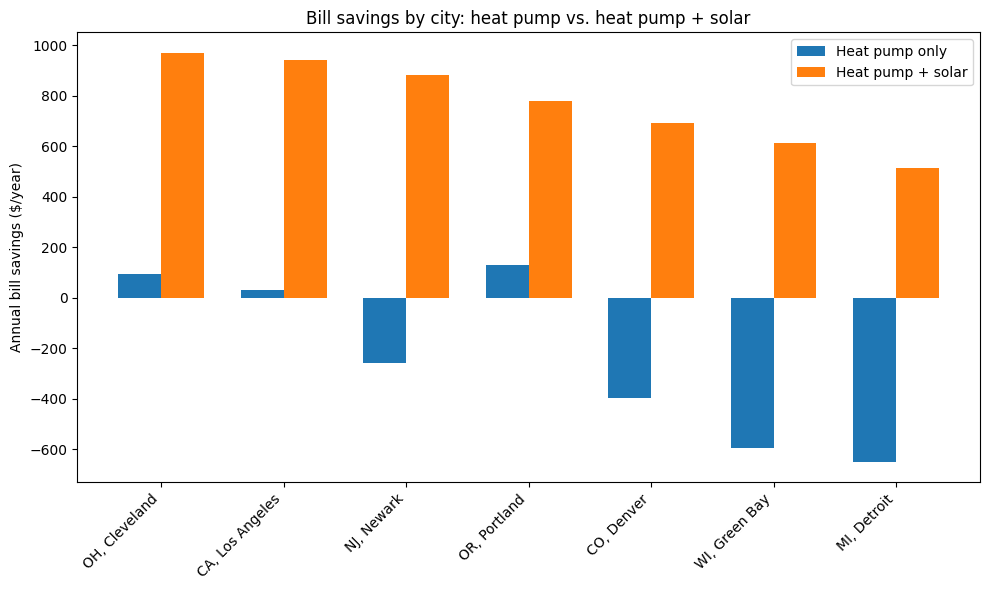

In [7]:
CITIES_TO_PLOT = bills_df['in.city'].unique().tolist()

plot_city_bill_savings(
    results_df=bills_df,
    cities=CITIES_TO_PLOT,
    figsize=(10, 6),
)